In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [32]:

df = pd.read_csv("data/housing.csv")

df.dropna(inplace=True)

# Average number of rooms per household
df["avg_rooms"] = df["total_rooms"] / df["households"]

# independent
X = df["avg_rooms"].values

# Dependent
y = df["median_house_value"].values

In [33]:
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,avg_rooms
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137


In [34]:
# Spliting data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [35]:
mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

print("Mean :", mean)
print("Standard Deviation :", std)

Mean : 5.424985927537479
Standard Deviation : 2.359803695972903


In [36]:
b0 = 0
b1 = 0


learning_rate = 0.01

# Number of iterations
iteration = 1000

n = len(X_train_norm)


cost = []

# Gradient Descent starts here
for i in range(iteration):

    # Calculate predicted values
    y_pred = b0 + b1 * X_train_norm

    # Calculate MSE
    mse = np.mean((y_train - y_pred) ** 2)

    # Store MSE
    cost.append(mse)

    # Calculate gradients
    db0 = (-2 / n) * np.sum(y_train - y_pred)

    db1 = (-2 / n) * np.sum(
        X_train_norm * (y_train - y_pred)
    )

    # Update parameters
    b0 = b0 - learning_rate * db0
    b1 = b1 - learning_rate * db1

print("b0 =", b0)
print("b1 =", b1)

b0 = 206644.39975010746
b1 = 18591.866482570684


In [37]:

y_pred_gd = b0 + b1 * X_test_norm

mse_gd = mean_squared_error(y_test, y_pred_gd)

r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent")
print("MSE :", mse_gd)
print("R² Score :", r2_gd)

Gradient Descent
MSE : 13554754931.142567
R² Score : 0.008806161819007507


In [ ]:
#With iteration = 1000 
#MSE : 13554754931.142567
#R² Score : 0.008806161819007507
# It is very poor

#With iteration = 1000000
#Gradient Descent
#MSE : 13554754931.240023
#R² Score : 0.008806161811881208

#SO no meaningful change even if i change the iteration
#Issue is avg_rooms simply isn't giving a strong linear prediction


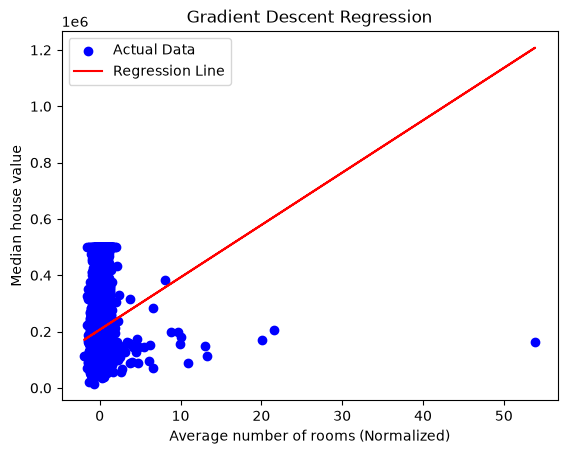

In [39]:
#Gradien desent graph
plt.scatter(
    X_test_norm,
    y_test,
    color="blue",
    label="Actual Data"
)

plt.plot(
    X_test_norm,
    y_pred_gd,
    color="red",
    label="Regression Line"
)

plt.xlabel("Average number of rooms (Normalized)")
plt.ylabel("Median house value")

plt.title("Gradient Descent Regression")

plt.legend()
plt.show()

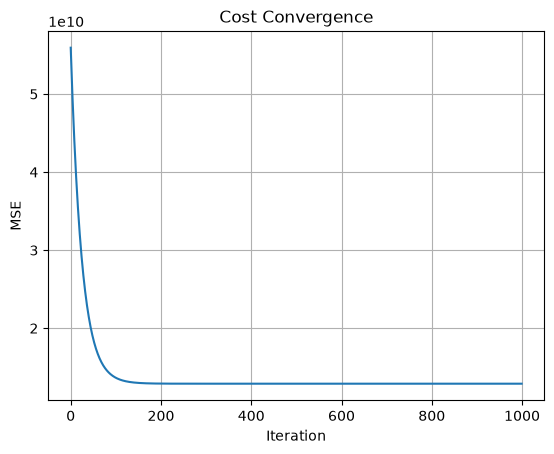

In [40]:
plt.plot(range(iteration), cost)


plt.xlabel("Iteration")

plt.ylabel("MSE")

plt.title("Cost Convergence")

plt.grid(True)
plt.show()

In [41]:

model = LinearRegression()

model.fit(
    X_train.reshape(-1, 1),
    y_train
)


y_predict = model.predict(
    X_test.reshape(-1, 1)
)

mse_lr = mean_squared_error(y_test, y_predict)

r2_lr = r2_score(y_test, y_predict)

print("Linear Regression")
print("-----------------")
print("MSE :", mse_lr)
print("R² Score :", r2_lr)

print("Slope (m) :", model.coef_[0])
print("Intercept (c) :", model.intercept_)

Linear Regression
-----------------
MSE : 13554754931.240023
R² Score : 0.008806161811881208
Slope (m) : 7878.564876217428
Intercept (c) : 163903.29651521269


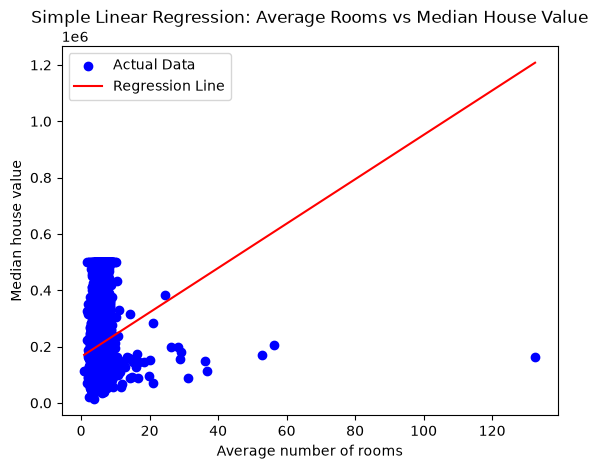

In [42]:

m = model.coef_[0]
c = model.intercept_

# Actual test data
plt.scatter(
    X_test,
    y_test,
    color="blue",
    label="Actual Data"
)


x_line = np.sort(X_test)

y_line = m * x_line + c

plt.plot(
    x_line,
    y_line,
    color="red",
    label="Regression Line"
)

plt.title(
    "Simple Linear Regression: Average Rooms vs Median House Value"
)

plt.xlabel("Average number of rooms")
plt.ylabel("Median house value")

plt.legend()
plt.show()

In [44]:
#Comparisomn
#Not in the actual code

In [45]:
comparison = pd.DataFrame({
    "Model": ["Gradient Descent", "Linear Regression"],
    "MSE": [mse_gd, mse_lr],
    "R² Score": [r2_gd, r2_lr]
})

comparison

,Model,MSE,R² Score
0,Gradient Descent,1.355475e+10,0.008806
1,Linear Regression,1.355475e+10,0.008806
